# Lesson 0006: embeddings, the neural bigram learns the table

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tamnd/soroban/blob/main/lessons/0006-neural-bigram/lesson.ipynb)

Lesson 0005 built a bigram model by counting. This one builds the same model without counting: a matrix of weights, a softmax, and gradient descent. The trained weights reproduce the 0005 count table to the digit, because the loss gradient is predicted frequency minus observed frequency, so descent has nowhere to go but the data. The full writeup is in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0006-neural-bigram).

![the softmax matrix descending to the count table](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0006-neural-bigram/assets/descent.gif)

## 0. The corpus and the training pairs

Same three words as 0005, cat, cot, cab, wrapped in the [boundary token](https://github.com/tamnd/soroban/blob/main/maths/notation.md) `.`. The twelve bigrams become twelve (current, next) training examples: the model will be graded on predicting each next letter from its current one.

In [1]:
import numpy as np, math

CORPUS = ["cat", "cot", "cab"]
ALPHABET = ['.', 'a', 'b', 'c', 'o', 't']
IDX = {c: i for i, c in enumerate(ALPHABET)}
V = len(ALPHABET)

def pairs():
    xs, ys = [], []
    for w in CORPUS:
        s = '.' + w + '.'
        for a, b in zip(s, s[1:]):
            xs.append(IDX[a]); ys.append(IDX[b])
    return np.array(xs), np.array(ys)

xs, ys = pairs()
print("pairs:", list(zip([ALPHABET[i] for i in xs], [ALPHABET[j] for j in ys])))
assert len(xs) == 12

pairs: [('.', 'c'), ('c', 'a'), ('a', 't'), ('t', '.'), ('.', 'c'), ('c', 'o'), ('o', 't'), ('t', '.'), ('.', 'c'), ('c', 'a'), ('a', 'b'), ('b', '.')]


## 1. The model: a weight matrix read one row at a time

The model is a 6x6 matrix `W`. To predict the letter after the current one, read that letter's row of `W`, six scores called logits. Reading a row by index is an [embedding](https://github.com/tamnd/soroban/blob/main/maths/embedding.md) lookup, the same thing as `onehot(current) @ W`. A [softmax](https://github.com/tamnd/soroban/blob/main/maths/softmax.md) turns the row into next-letter probabilities.

In [2]:
def softmax_rows(W):
    z = W - W.max(1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(1, keepdims=True)

def loss_of(W):
    P = softmax_rows(W)
    return np.mean([-math.log(P[xs[i], ys[i]]) for i in range(len(xs))])

W0 = np.zeros((V, V))            # maximum ignorance: every row uniform
print("P(next | c) at init:", np.round(softmax_rows(W0)[IDX['c']], 4))
print("init loss:", round(loss_of(W0), 6), " log 6 =", round(math.log(6), 6))
assert abs(loss_of(W0) - math.log(6)) < 1e-12

P(next | c) at init: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
init loss: 1.791759  log 6 = 1.791759


## 2. One gradient step, by hand and in code

The [cross-entropy](https://github.com/tamnd/soroban/blob/main/maths/cross-entropy.md) gradient on the logits is `p - y`, the predicted distribution minus the one-hot truth. Row c is looked up by three examples (c to a, c to o, c to a), so its gradient sums to `(0.5 - observed)/12`: most negative at a, the letter c most underweights. One step at learning rate 10 moves `W[c, a]` from 0 to 1.25.

In [3]:
def grad(W, reg=0.0):
    P = softmax_rows(W)
    G = np.zeros((V, V))
    for i in range(len(xs)):
        gi = P[xs[i]].copy(); gi[ys[i]] -= 1
        G[xs[i]] += gi
    return G / len(xs) + reg * W

G = grad(W0)
print("row c gradient:", np.round(G[IDX['c']], 6))
expect = np.array([(0.5 - o) / 12 for o in (0, 2, 0, 0, 1, 0)])   # cols . a b c o t
assert np.allclose(G[IDX['c']], expect)

W1 = W0 - 10 * G
print("W[c,a] after one step:", W1[IDX['c'], IDX['a']], " loss:", round(loss_of(W1), 6))
assert W1[IDX['c'], IDX['a']] == 1.25
assert abs(loss_of(W1) - 0.874450) < 1e-6

row c gradient: [ 0.041667 -0.125     0.041667  0.041667 -0.041667  0.041667]
W[c,a] after one step: 1.25  loss: 0.87445


## 3. Train to convergence

Keep stepping. The row-c gradient is zero only when its softmax equals the observed frequencies (a: 2/3, o: 1/3), the 0005 count-table row, so descent walks there. After 200 steps the loss is 0.277674 and a|c is 0.665334: the count table, learned. It never quite reaches the exact 2/3, because a softmax cannot output the exact zeros the table has without infinite weights.

In [4]:
def train(lr, steps, reg=0.0):
    W = np.zeros((V, V))
    for _ in range(steps):
        W = W - lr * grad(W, reg)
    return W

W = train(10, 200)
P = softmax_rows(W)
print("loss:", round(loss_of(W), 6), " min log(3)/4 =", round(math.log(3)/4, 6))
print("a|c:", round(P[IDX['c'], IDX['a']], 6), " o|c:", round(P[IDX['c'], IDX['o']], 6))
assert abs(loss_of(W) - 0.277674) < 1e-5
assert abs(P[IDX['c'], IDX['a']] - 0.665334) < 1e-5
assert math.log(3)/4 < loss_of(W)     # approached from above

loss: 0.277674  min log(3)/4 = 0.274653
a|c: 0.665334  o|c: 0.331997


The trained softmax as a heatmap, computed live. Compare it to the 0005 count table: same numbers, reached by learning instead of counting.

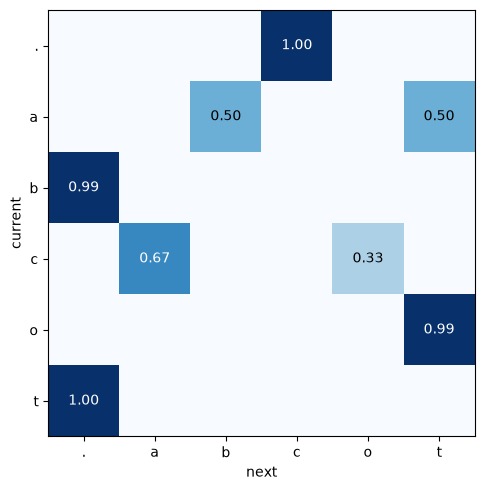

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(P, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(V)); ax.set_xticklabels(ALPHABET)
ax.set_yticks(range(V)); ax.set_yticklabels(ALPHABET)
ax.set_xlabel("next"); ax.set_ylabel("current")
for i in range(V):
    for j in range(V):
        if P[i, j] > 0.02:
            ax.text(j, i, f"{P[i, j]:.2f}", ha='center', va='center',
                    color='white' if P[i, j] > 0.5 else 'black')
plt.tight_layout(); plt.show()

## 4. Sample: the learned table writes the words back

Walk the trained softmax with the same fixed dice lesson 0005 used: start at `.`, take a roll, and walk the current row's cumulative probabilities until the running total reaches the roll. Because the trained probabilities are within a thousandth of the counts, the same dice produce the same words.

In [6]:
DICE = [0.5,0.2,0.8,0.5, 0.5,0.9,0.5,0.5, 0.5,0.2,0.3,0.5]

def sample(W, dice, n_words=3):
    P = softmax_rows(W); it = iter(dice); words = []
    for _ in range(n_words):
        cur, out = IDX['.'], []
        while True:
            u = next(it); cum = 0.0; nxt = IDX['.']
            for s in range(V):
                cum += P[cur, s]
                if cum >= u: nxt = s; break
            if nxt == IDX['.']:
                break
            out.append(ALPHABET[nxt]); cur = nxt
        words.append(''.join(out))
    return words

print("sampled:", sample(W, DICE))
assert sample(W, DICE) == ["cat", "cot", "cab"]

sampled: ['cat', 'cot', 'cab']


## 5. Break it: the learning rate is too high

At learning rate 10 the loss descends. At 50 it does not: the deterministic rows overshoot their target every step and the gradient flips sign, so the loss oscillates on a repeating sawtooth and never converges. Unlike lesson 0001, it cannot explode to infinity, because the cross-entropy gradient is bounded; the worst it does is bounce.

In [7]:
Wh = np.zeros((V, V)); losses = []
for _ in range(6):
    Wh = Wh - 50 * grad(Wh); losses.append(round(loss_of(Wh), 4))
print("lr 50 losses:", losses)
assert losses[:3] == [0.4846, 0.7636, 1.1527]

lr 50 losses: [np.float64(0.4846), np.float64(0.7636), np.float64(1.1527), np.float64(0.4615), np.float64(0.7753), np.float64(1.1448)]


## 6. The zero-frequency problem is gone

Lesson 0005's dog had infinite loss because one bigram had a count of zero. Here, an unseen bigram like c to t has probability 0.000667, not 0: a softmax over finite scores can never output an exact zero, so nothing is ever impossible. The neural model has 0005's smoothing built into its shape.

In [8]:
ct = softmax_rows(W)[IDX['c'], IDX['t']]
print("P(t | c):", round(ct, 6), "  (count model said 0)")
assert ct > 0 and abs(ct - 0.000667) < 1e-5

P(t | c): 0.000667   (count model said 0)


## 7. Exit test: regularization is smoothing with a dial

Add an L2 penalty (`+ reg * W` in the gradient). It pulls every weight toward zero, whose softmax is uniform, so it moves probability off the observed letters and toward 1/6, exactly what add-one smoothing did in 0005, now a continuous knob.

In [9]:
Wr = train(10, 200, reg=0.10); Pr = softmax_rows(Wr)
print("reg 0.10  a|c:", round(Pr[IDX['c'], IDX['a']], 6), " c->t:", round(Pr[IDX['c'], IDX['t']], 6))
assert abs(Pr[IDX['c'], IDX['a']] - 0.340214) < 1e-5
assert abs(Pr[IDX['c'], IDX['t']] - 0.113314) < 1e-5

reg 0.10  a|c: 0.340214  c->t: 0.113314


## 8. Torch agrees

The same model trained with `torch.optim.SGD` lands on the same loss and the same rows, the same arithmetic in a different tool.

In [10]:
try:
    import torch

    Wt = torch.zeros((V, V), dtype=torch.float64, requires_grad=True)
    xt, yt = torch.tensor(xs), torch.tensor(ys)
    opt = torch.optim.SGD([Wt], lr=10.0)
    for _ in range(200):
        opt.zero_grad()
        logits = Wt[xt]
        logp = logits - torch.logsumexp(logits, 1, keepdim=True)
        loss = -logp[torch.arange(len(xs)), yt].mean()
        loss.backward(); opt.step()
    Pt = torch.softmax(Wt, 1)
    print("torch loss:", round(loss.item(), 6),
          " a|c:", round(Pt[IDX['c'], IDX['a']].item(), 6))
    assert abs(loss.item() - 0.277674) < 1e-3
    print("torch agrees with the numpy run")
except ImportError:
    print("torch not installed, skipping (Colab has it preinstalled)")

torch loss: 0.277689  a|c: 0.665334
torch agrees with the numpy run


## Exercises

1. Predict the sign of the gradient at `W[a, t]` on the first step. a is followed by t once and b once; is t under- or over-weighted at the uniform start?
2. The trained a|c is 0.665334, short of 2/3. Would 2000 steps get closer, or is there a floor it cannot pass? (What would the exact 2/3 require of the weights?)
3. Score o to t in the trained model. The count model gives 1. Is the neural number exactly 1, above, or just below, and does exercise 2 explain it?

Worked answers are in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0006-neural-bigram) and asserted in `train.py`. Lesson 0007 adds attention, letting the model look at more than one previous letter, and the embedding built here becomes the transformer's first layer.